In [1]:
import os
import glob
import gc
from pathlib import Path

import numpy as np
import pandas as pd

from statsmodels.stats.multitest import multipletests
from upsetplot import from_contents, generate_counts, UpSet, plot, from_indicators

import matplotlib.pyplot as plt
import seaborn as sns

import anndata as ad
import scanpy as sc

%matplotlib inline

In [2]:
## Read IN ##

CSV_PATH = '/mnt/sdb/scz_meta_analysis_processed/dge_signatures/dreamlet_dges/disease_analyses/'

# fe_analysis #

fe_dge_nrxn1 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_nrxn1_combined.csv')
fe_dge_22q11 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_22q11_combined.csv')
fe_dge_idiopathic = pd.read_csv(Path(CSV_PATH) / 'dreamlet_idiopathic_combined.csv')

# add assay ID cols #

fe_dge_nrxn1['assay_ID'] = fe_dge_nrxn1['assay'].astype('str') + ' | '  +  fe_dge_nrxn1['ID'].astype('str')
fe_dge_22q11['assay_ID'] = fe_dge_22q11['assay'].astype('str') + ' | '  +  fe_dge_22q11['ID'].astype('str')
fe_dge_idiopathic['assay_ID'] = fe_dge_idiopathic['assay'].astype('str') + ' | '  +  fe_dge_idiopathic['ID'].astype('str')

In [3]:
# re_analysis #

re_dge_nrxn1 = pd.read_csv(Path(CSV_PATH) / 'random_dreamlet_nrxn1_combined.csv')
re_dge_22q11 = pd.read_csv(Path(CSV_PATH) / 'random_dreamlet_22q11_combined.csv')
re_dge_idiopathic = pd.read_csv(Path(CSV_PATH) / 'random_dreamlet_idiopathic_combined.csv')

# add assay ID cols #

re_dge_nrxn1['assay_ID'] = re_dge_nrxn1['assay'].astype('str') + ' | '  +  re_dge_nrxn1['ID'].astype('str')
re_dge_22q11['assay_ID'] = re_dge_22q11['assay'].astype('str') + ' | '  +  re_dge_22q11['ID'].astype('str')
re_dge_idiopathic['assay_ID'] = re_dge_idiopathic['assay'].astype('str') + ' | '  +  re_dge_idiopathic['ID'].astype('str')

In [4]:
## FDR Calculation Function ##

def fdr_per_celltype(dge_df):
    """Add FDR-adjusted p-values and significance per cell type."""
    dge_df['p.adjusted'] = None
    dge_df['significant_fdr'] = False
    
    for celltype, group in dge_df.groupby('assay'):
        rejected, pvals_corrected, _, _ = multipletests(group['p.value'], method='fdr_bh')
        dge_df.loc[group.index, 'p.adjusted'] = pvals_corrected
        dge_df.loc[group.index, 'significant_fdr'] = rejected
    
    return dge_df

In [5]:
## Subclass #

subclass_dge_list = []
for file_path in glob.glob('/mnt/sdb/scz_meta_analysis_processed/dge_signatures/dreamlet_dges/one_vs_all/subclass/DE_*'):
    dge = pd.read_csv(file_path, index_col=0)
    #dge = dge[(dge['adj.P.Val'] < 0.05) & (dge['logFC'] > 1)].sort_values(by='AveExpr', ascending=False)
    subclass_dge_list.append(dge)

subclass_dges = pd.concat(subclass_dge_list, axis=0)

subclass_dges = subclass_dges[~pd.Series(subclass_dges.index).str.contains('ENSG').values]

In [6]:
## Subtypes ##

subtype_dge_list = []
for file_path in glob.glob('/mnt/sdb/scz_meta_analysis_processed/dge_signatures/dreamlet_dges/one_vs_all/subtypes_remerged/DE_*'):
    dge = pd.read_csv(file_path, index_col=0)
    # dge = dge[(dge['adj.P.Val'] < 0.05) & (dge['logFC'] > 1)].sort_values(by='AveExpr', ascending=False)
    subtype_dge_list.append(dge)

subtypes_dges = pd.concat(subtype_dge_list, axis=0)

subtypes_dges = subtypes_dges[~pd.Series(subtypes_dges.index).str.contains('ENSG').values]

In [7]:
subclass_annotations_markers = {"1_1": "Radial Glia SOX2+VIM+FABP7+",
                                "1_2": "Proliferative Radial Glia SOX2+HES6+TOP2A+",
                                "1_3": "Radial Glia SOX2+PAX6+FABP7+",
                                "1_4": "Mesenchymal-like cells VIM+VCAN+SPARC+",
                                "1_5": "Stressed Glia FTL+B2M+GLUL+",
                                "2_1": "Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+",
                                "2_2": "Hindbrain Neurons NR2F2+PBX3+LHX1+",
                                "2_3": "Mixed Neurons FGF12+GRIN2B+CAMK2B+",
                                "2_4": "GABAergic GAD1+GAD2+CALB2+"}

subclass_annotations = {"1_1": "Radial Glia",
                        "1_2": "Proliferative Radial Glia",
                        "1_3": "Radial Glia",
                        "1_4": "Mesenchymal-like cells",
                        "1_5": "Stressed Glia",
                        "2_1": "Dorsal Forebrain EN",
                        "2_2": "Hindbrain Neurons",
                        "2_3": "Mixed Neurons",
                        "2_4": "GABAergic"}

In [8]:
subclass_dges['subclass_annotated'] = subclass_dges['subclass'].map(subclass_annotations_markers)

In [9]:
fe_dge_nrxn1 = fdr_per_celltype(fe_dge_nrxn1)
fe_dge_22q11 = fdr_per_celltype(fe_dge_22q11)
fe_dge_idiopathic = fdr_per_celltype(fe_dge_idiopathic)

In [10]:
re_dge_nrxn1 = fdr_per_celltype(re_dge_nrxn1)
re_dge_22q11 = fdr_per_celltype(re_dge_22q11)
re_dge_idiopathic = fdr_per_celltype(re_dge_idiopathic)

In [11]:
# Celltype #

fe_all_celltypes = pd.concat([fe_dge_idiopathic.assign(group='Idiopathic Schizophrenia'),
                                fe_dge_nrxn1.assign(group='NRXN1del'), 
                                fe_dge_22q11.assign(group='22q11.2del')], axis=0)

fe_significant_all = fe_all_celltypes[fe_all_celltypes['significant_fdr']]

In [32]:
# Celltype #

re_all_celltypes = pd.concat([re_dge_idiopathic.assign(group='Idiopathic Schizophrenia'),
                                re_dge_nrxn1.assign(group='NRXN1del'), 
                                re_dge_22q11.assign(group='22q11.2del')], axis=0)

re_significant_all = re_all_celltypes[re_all_celltypes['significant_fdr']]

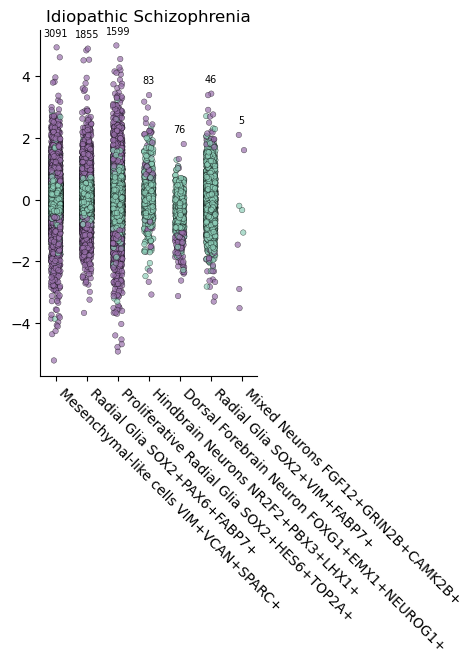

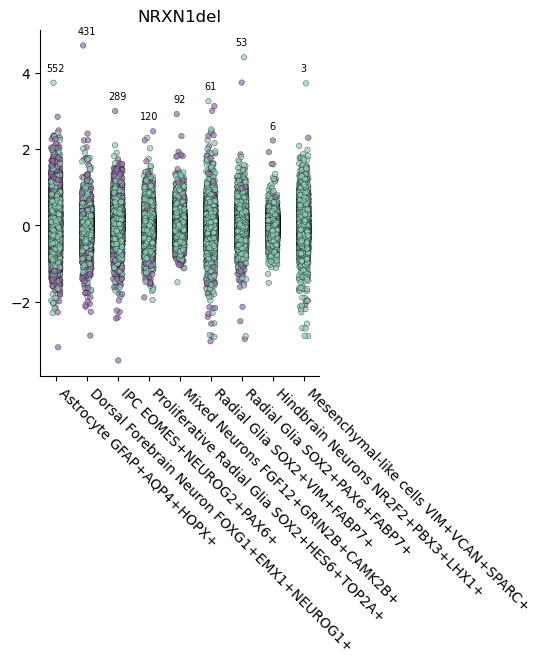

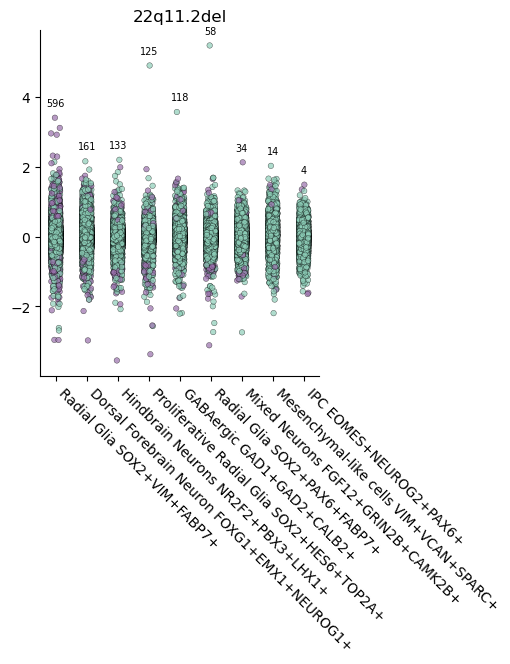

In [14]:
assay_order = sorted(fe_all_celltypes["assay"].unique())

palette = dict(zip(assay_order, sns.color_palette("tab10", n_colors=len(assay_order))))

# ensure boolean dtype
fe_all_celltypes["significant_fdr"] = fe_all_celltypes["significant_fdr"].astype(bool)

sig_palette = {False: "#8dceb8ff", True: "#9970ab"}

hue_order = [False, True]

for disease in fe_all_celltypes["group"].unique():

    temp_df = fe_all_celltypes.loc[fe_all_celltypes["group"] == disease].copy()

    significant_celltypes = (
        temp_df.groupby("assay")["significant_fdr"]
        .any()
        .loc[lambda s: s]
        .index
    )
    temp_df = temp_df[temp_df["assay"].isin(significant_celltypes)]

    if temp_df.shape[0] == 0:
        continue

    # Count significant hits per assay
    sig_counts = (
        temp_df[temp_df["significant_fdr"]]
        .groupby("assay")
        .size()
    )

    # Order assays from most to fewest significant hits (ties alphabetically)
    present_assays = (
        sig_counts.rename("n")
        .reset_index()
        .sort_values(["n", "assay"], ascending=[False, True])
        ["assay"]
        .tolist()
    )

    fig, ax = plt.subplots(figsize=(len(present_assays) * 0.4, 4.5))

    sns.stripplot(
        data=temp_df,
        x="assay",
        y="estimate",
        order=present_assays,
        hue="significant_fdr",
        hue_order=hue_order,
        palette=sig_palette,
        jitter=0.15,
        size=4,
        alpha=0.7,
        edgecolor="black",
        linewidth=0.3,
        ax=ax,
    )

    # remove duplicate legends
    if ax.legend_ is not None:
        ax.legend_.remove()

    ax.set_title(disease)
    ax.set_xlabel("")
    ax.set_ylabel("")

    sns.despine()
    plt.xticks(rotation=-45, ha="left")

    # Add number of significant hits above each assay
    yrange = temp_df["estimate"].max() - temp_df["estimate"].min()

    for x, assay in enumerate(present_assays):
        y = temp_df.loc[temp_df["assay"] == assay, "estimate"].max()
        n = sig_counts.get(assay, 0)

        ax.text(
            x,
            y + 0.03 * yrange,
            str(n),
            ha="center",
            va="bottom",
            fontsize=7,
            color="black",
        )

    # Save version WITH labels

    plt.show()

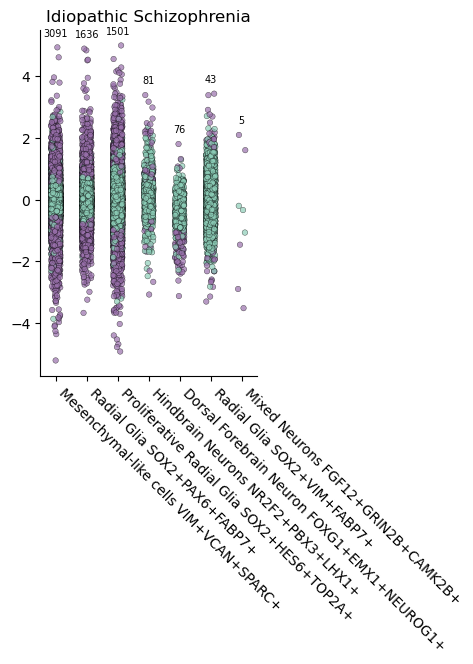

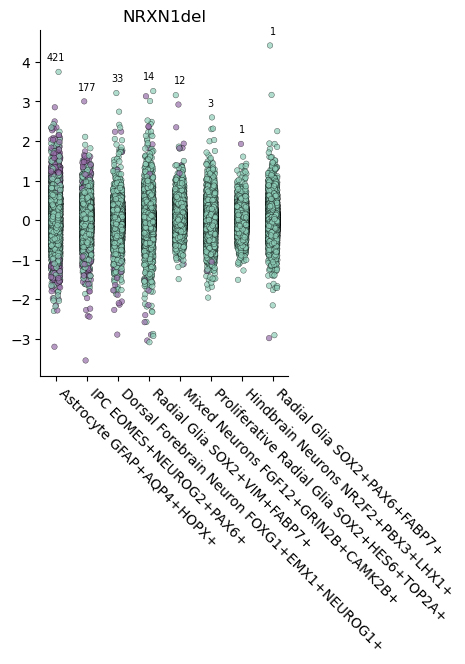

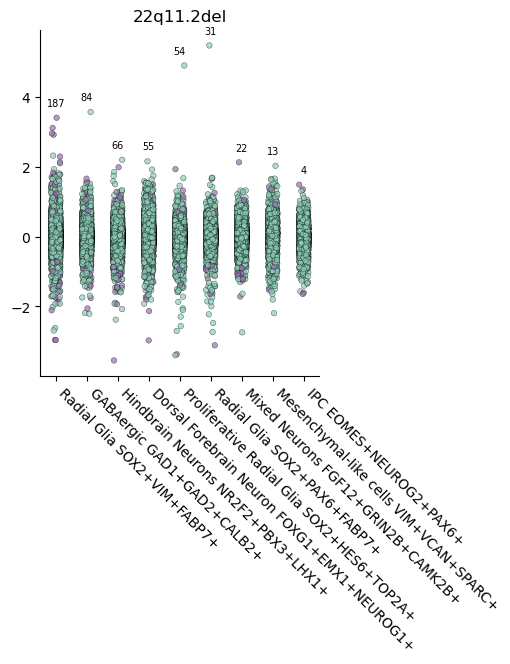

In [16]:
assay_order = sorted(re_significant_all["assay"].unique())

palette = dict(zip(assay_order, sns.color_palette("tab10", n_colors=len(assay_order))))

# ensure boolean dtype
re_all_celltypes["significant_fdr"] = re_all_celltypes["significant_fdr"].astype(bool)

sig_palette = {False: "#8dceb8ff", True: "#9970ab"}

hue_order = [False, True]

for disease in re_all_celltypes["group"].unique():

    temp_df = re_all_celltypes.loc[re_all_celltypes["group"] == disease].copy()

    significant_celltypes = (
        temp_df.groupby("assay")["significant_fdr"]
        .any()
        .loc[lambda s: s]
        .index
    )
    temp_df = temp_df[temp_df["assay"].isin(significant_celltypes)]

    if temp_df.shape[0] == 0:
        continue

    # Count significant hits per assay
    sig_counts = (
        temp_df[temp_df["significant_fdr"]]
        .groupby("assay")
        .size()
    )

    # Order assays from most to fewest significant hits (ties alphabetically)
    present_assays = (
        sig_counts.rename("n")
        .reset_index()
        .sort_values(["n", "assay"], ascending=[False, True])
        ["assay"]
        .tolist()
    )

    fig, ax = plt.subplots(figsize=(len(present_assays) * 0.4, 4.5))

    sns.stripplot(
        data=temp_df,
        x="assay",
        y="estimate",
        order=present_assays,
        hue="significant_fdr",
        hue_order=hue_order,
        palette=sig_palette,
        jitter=0.15,
        size=4,
        alpha=0.7,
        edgecolor="black",
        linewidth=0.3,
        ax=ax,
    )

    # remove duplicate legends
    if ax.legend_ is not None:
        ax.legend_.remove()

    ax.set_title(disease)
    ax.set_xlabel("")
    ax.set_ylabel("")

    sns.despine()
    plt.xticks(rotation=-45, ha="left")

    # Add number of significant hits above each assay
    yrange = temp_df["estimate"].max() - temp_df["estimate"].min()

    for x, assay in enumerate(present_assays):
        y = temp_df.loc[temp_df["assay"] == assay, "estimate"].max()
        n = sig_counts.get(assay, 0)

        ax.text(
            x,
            y + 0.03 * yrange,
            str(n),
            ha="center",
            va="bottom",
            fontsize=7,
            color="black",
        )

    # Save version WITH labels

    plt.show()

In [17]:
def plot_assay_upset(df, assay_col='assay',  gene_col='ID', significance_col='significant_fdr', 
                     min_size=1, dataset_label="", top_graph=True, side_graph=True, title=True, save=False):

    # Filter significant genes (optional but recommended)
    if significance_col in df.columns:
        df = df[df[significance_col] == True]
    
    # Build gene sets per assay
    assay_sets = {assay: set(group[gene_col])  for assay, group in df.groupby(assay_col)}
    
    # Remove very small sets if desired
    assay_sets = {k: v for k, v in assay_sets.items() if len(v) >= min_size}
    
    # Convert to upset format
    upset_data = from_contents(assay_sets)
    
    # Plot
    plt.figure(figsize=(10, 6))

    if top_graph and side_graph:
        upset = UpSet(upset_data, show_counts=True, sort_by='degree')
    elif top_graph and not side_graph:
        upset = UpSet(upset_data, show_counts=True, with_lines=True, element_size=49, totals_plot_elements=0)
    elif side_graph and not top_graph:
        upset = UpSet(upset_data, show_counts=True, with_lines=True, element_size=49, intersection_plot_elements=())
    elif not top_graph and not side_graph:
        upset = UpSet(upset_data, show_counts=True, with_lines=True, element_size=49, intersection_plot_elements=(), totals_plot_elements=0)
    
    upset.plot()

    if title != None:
        title = f"{dataset_label} Shared DGEs"
        plt.suptitle(title)
        
    # if save:
    #     plt.savefig(f"/home/deepak/datasets/scz_meta_analysis/panels/Fig_3_{dataset_label}_upset.svg")
    
    plt.show()

In [18]:
significant_all = pd.concat([re_significant_all, fe_significant_all], axis=0)

In [28]:
re_significant_all[re_significant_all['assay'] == 'Proliferative Radial Glia SOX2+HES6+TOP2A+']['ID'].unique().shape

(1553,)

In [64]:
fe_all = pd.concat([
    fe_dge_idiopathic.assign(group='Idiopathic Schizophrenia'),
    fe_dge_nrxn1.assign(group='NRXN1del'),
    fe_dge_22q11.assign(group='22q11.2del')
], ignore_index=True)

re_all = pd.concat([
    re_dge_idiopathic.assign(group='Idiopathic Schizophrenia'),
    re_dge_nrxn1.assign(group='NRXN1del'),
    re_dge_22q11.assign(group='22q11.2del')
], ignore_index=True)

# Check duplicates
fe_dupes = fe_all.groupby(['assay','ID','group']).size().reset_index(name='n').query('n > 1')
re_dupes = re_all.groupby(['assay','ID','group']).size().reset_index(name='n').query('n > 1')
print("FE duplicate rows:", len(fe_dupes))
print("RE duplicate rows:", len(re_dupes))
if len(fe_dupes): display(fe_dupes.head())
if len(re_dupes): display(re_dupes.head())

# Select + rename
fe = fe_all[['assay','ID','group','estimate','std.error','statistic','p.value','p.adjusted','significant_fdr']].rename(columns={
    'estimate':'estimate_FE','std.error':'std.error_FE','statistic':'statistic_FE',
    'p.value':'p.value_FE','p.adjusted':'FDR_FE','significant_fdr':'significant_fdr_FE'
})

re = re_all[['assay','ID','group','estimate','std.error','statistic','p.value','p.adjusted','significant_fdr','I2','n.studies','method']].rename(columns={
    'estimate':'estimate_RE','std.error':'std.error_RE','statistic':'statistic_RE',
    'p.value':'p.value_RE','p.adjusted':'FDR_RE','significant_fdr':'significant_fdr_RE'
})

# Merge
comparison = fe.merge(re, on=['assay','ID','group'], how='outer', validate='one_to_one')

comparison[['significant_fdr_FE','significant_fdr_RE']] = (
    comparison[['significant_fdr_FE','significant_fdr_RE']].fillna(False).astype(bool)
)

# FE vs RE differences
comparison['delta_effect'] = comparison['estimate_RE'] - comparison['estimate_FE']
comparison['delta_se'] = comparison['std.error_RE'] - comparison['std.error_FE']
comparison['abs_delta_effect'] = comparison['delta_effect'].abs()
comparison['abs_delta_se'] = comparison['delta_se'].abs()

# Classify
comparison['category'] = np.select(
    [
        comparison.significant_fdr_FE & comparison.significant_fdr_RE,
        comparison.significant_fdr_FE & ~comparison.significant_fdr_RE,
        ~comparison.significant_fdr_FE & comparison.significant_fdr_RE
    ],
    ['FE + RE','FE only','RE only'],
    default='Neither'
)

# Subsets
re_only = comparison[(~comparison.significant_fdr_FE) & comparison.significant_fdr_RE].copy()
fe_only = comparison[comparison.significant_fdr_FE & (~comparison.significant_fdr_RE)].copy()
both = comparison[comparison.significant_fdr_FE & comparison.significant_fdr_RE].copy()

print("======================================")
print("FE vs RE significance")
print("======================================")
print(f"FE + RE hits : {len(both):,}")
print(f"FE-only hits : {len(fe_only):,}")
print(f"RE-only hits : {len(re_only):,}")
print(f"RE ⊆ FE      : {len(re_only) == 0}")
print("======================================")

# Summary
hit_summary = (
    comparison.groupby(['assay','group','category']).size()
    .unstack(fill_value=0).reset_index()
    .reindex(columns=['assay','group','FE + RE','FE only','RE only','Neither'], fill_value=0)
    .rename(columns={'FE + RE':'FE_RE_hits','FE only':'FE_only_hits','RE only':'RE_only_hits','Neither':'neither'})
)

hit_summary['FE_hits'] = hit_summary['FE_RE_hits'] + hit_summary['FE_only_hits']
hit_summary['RE_hits'] = hit_summary['FE_RE_hits'] + hit_summary['RE_only_hits']
hit_summary['RE_retention'] = np.where(hit_summary['FE_hits'] > 0, hit_summary['RE_hits'] / hit_summary['FE_hits'], np.nan)
hit_summary['RE_retention_pct'] = hit_summary['RE_retention'] * 100
hit_summary['FE_hits_lost'] = hit_summary['FE_hits'] - hit_summary['RE_hits']

hit_summary = hit_summary.sort_values(['group','RE_retention']).reset_index(drop=True)

display(hit_summary[['assay','group','FE_hits','RE_hits','FE_hits_lost','RE_retention_pct',
                     'FE_RE_hits','FE_only_hits','RE_only_hits']])

# Sanity checks
print("\n======================================")
print("Sanity checks")
print("======================================")
print("Number of RE-only genes:", len(re_only))
print("Number of FE-only genes:", len(fe_only))
print("Number of genes significant in both:", len(both))
print("Maximum RE-only hits in any cell type × disease:", hit_summary['RE_only_hits'].max())
print("Minimum RE retention among combinations with ≥1 FE hit:",
      hit_summary.loc[hit_summary['FE_hits'] > 0, 'RE_retention_pct'].min())

assert len(re_only) == 0, "There are RE-only hits. Check the comparison before assuming RE is a subset of FE."
print("\n✓ All RE-significant genes are also FE-significant.")

FE duplicate rows: 0
RE duplicate rows: 0
FE vs RE significance
FE + RE hits : 7,611
FE-only hits : 1,994
RE-only hits : 0
RE ⊆ FE      : True


category,assay,group,FE_hits,RE_hits,FE_hits_lost,RE_retention_pct,FE_RE_hits,FE_only_hits,RE_only_hits
0,Radial Glia SOX2+VIM+FABP7+,22q11.2del,596,187,409,31.375839,187,409,0
1,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,22q11.2del,161,55,106,34.161491,55,106,0
2,Proliferative Radial Glia SOX2+HES6+TOP2A+,22q11.2del,125,54,71,43.200000,54,71,0
3,Hindbrain Neurons NR2F2+PBX3+LHX1+,22q11.2del,133,66,67,49.624060,66,67,0
4,Radial Glia SOX2+PAX6+FABP7+,22q11.2del,58,31,27,53.448276,31,27,0
5,Mixed Neurons FGF12+GRIN2B+CAMK2B+,22q11.2del,34,22,12,64.705882,22,12,0
6,GABAergic GAD1+GAD2+CALB2+,22q11.2del,118,84,34,71.186441,84,34,0
7,Mesenchymal-like cells VIM+VCAN+SPARC+,22q11.2del,14,13,1,92.857143,13,1,0
8,IPC EOMES+NEUROG2+PAX6+,22q11.2del,4,4,0,100.000000,4,0,0
9,Astrocyte GFAP+AQP4+HOPX+,22q11.2del,0,0,0,NaN,0,0,0



Sanity checks
Number of RE-only genes: 0
Number of FE-only genes: 1994
Number of genes significant in both: 7611
Maximum RE-only hits in any cell type × disease: 0
Minimum RE retention among combinations with ≥1 FE hit: 0.0

✓ All RE-significant genes are also FE-significant.


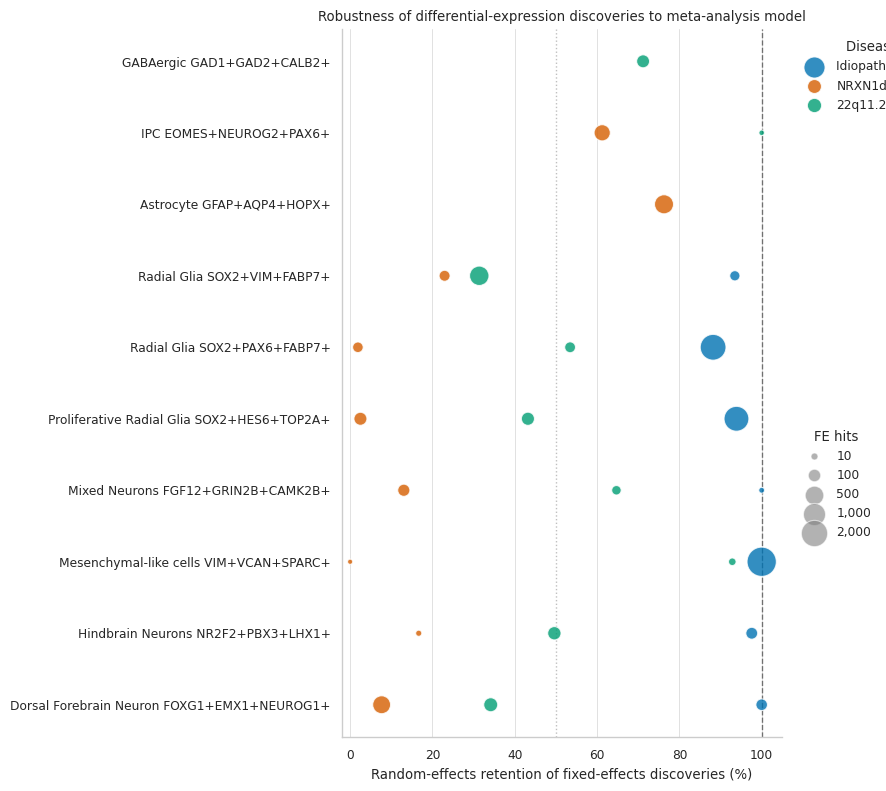

In [117]:
plot_df = hit_summary[hit_summary['FE_hits'] > 0].copy()

order = plot_df.groupby('assay')['RE_retention_pct'].mean().sort_values().index
plot_df['assay'] = pd.Categorical(plot_df['assay'], categories=order, ordered=True)

sns.set_theme(style='whitegrid', context='paper')
fig, ax = plt.subplots(figsize=(9, 8))

palette = {'Idiopathic Schizophrenia':'#0072B2', 'NRXN1del':'#D55E00', '22q11.2del':'#009E73'}

for disease, color in palette.items():
    sub = plot_df[plot_df['group'] == disease]
    ax.scatter(sub['RE_retention_pct'], sub['assay'], s=np.sqrt(sub['FE_hits'])*8,
               c=color, alpha=.8, edgecolor='white', linewidth=.8, label=disease, zorder=3)

ax.axvline(100, color='black', ls='--', lw=1, alpha=.5)
ax.axvline(50, color='gray', ls=':', lw=1, alpha=.5)
ax.set(xlim=(-2, 105), xlabel='Random-effects retention of fixed-effects discoveries (%)',
       ylabel='', title='Robustness of differential-expression discoveries to meta-analysis model')
ax.grid(axis='x', color='lightgray', lw=.7, alpha=.7); ax.grid(axis='y', visible=False)
sns.despine(ax=ax)

legend = ax.legend(title='Disease group', frameon=False, bbox_to_anchor=(1.02, 1), loc='upper left')

sizes = [10, 100, 500, 1000, 2000]
size_handles = [plt.scatter([], [], s=np.sqrt(n)*8, color='gray', alpha=.6, edgecolor='white', lw=.8, label=f'{n:,}') for n in sizes]
ax.legend(handles=size_handles, title='FE hits', frameon=False, bbox_to_anchor=(1.02, .45), loc='upper left', scatterpoints=1)
ax.add_artist(legend)
plt.savefig('/home/deepak/datasets/scz_meta_analysis/panels/Supplemental_Figure_RE_Comparison_dotplot_retention.svg')
plt.tight_layout()
plt.show()

/tmp/ipykernel_490828/3958839051.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


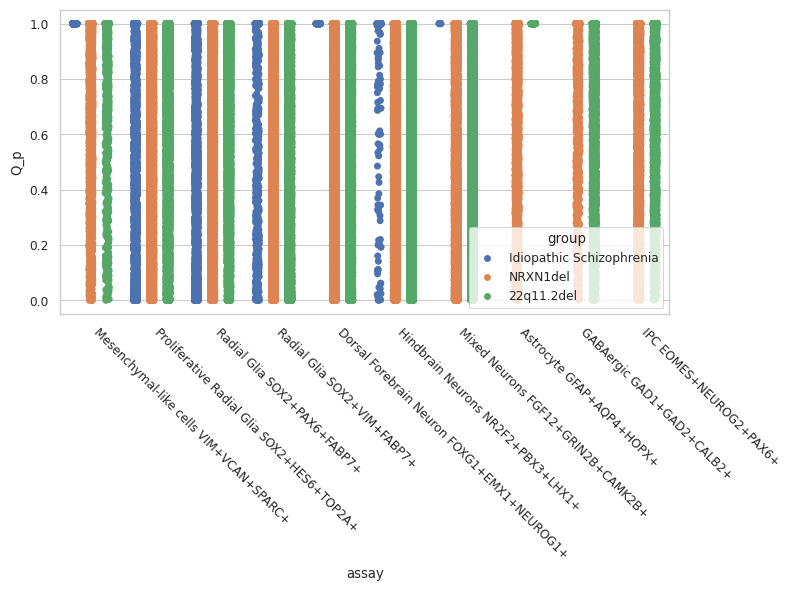

In [61]:
fig, ax = plt.subplots(figsize=(8, 6))

ax = sns.stripplot(data=re_all_celltypes, x='assay', hue='group', dodge=True, jitter=True, y='Q_p')

ax.set_xticklabels(ax.get_xticklabels(), rotation=-45, ha='left')

plt.tight_layout()

/tmp/ipykernel_490828/3366226530.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


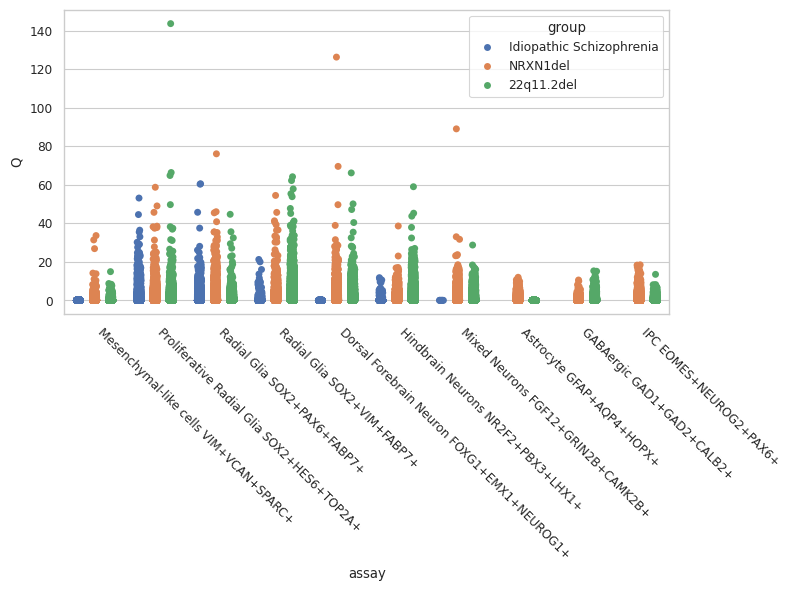

In [131]:
fig, ax = plt.subplots(figsize=(8, 6))

ax = sns.stripplot(
    data=re_all_celltypes,
    x='assay',
    hue='group',
    dodge=True,
    jitter=True,
    y='Q'
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=-45,
    ha='left')

plt.tight_layout()

plt.savefig('/home/deepak/datasets/scz_meta_analysis/panels/Supplemental_Figure_RE_Comparison_stripplot_cochranes_Q.png')

/tmp/ipykernel_490828/2568701319.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=-45, ha='left')


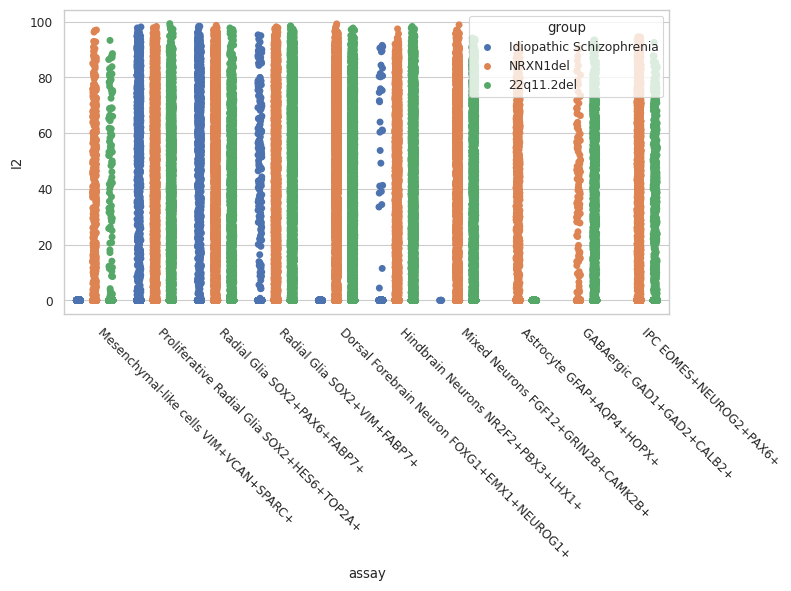

In [129]:
fig, ax = plt.subplots(figsize=(8, 6))

ax = sns.stripplot(data=re_all_celltypes, x='assay', hue='group', dodge=True, jitter=True, y='I2')

ax.set_xticklabels(ax.get_xticklabels(), rotation=-45, ha='left')

plt.tight_layout()
plt.savefig('/home/deepak/datasets/scz_meta_analysis/panels/Supplemental_Figure_RE_Comparison_stripplot_I2.png')

In [77]:
comparison['assay_disease'] = comparison['assay'].astype('str') + '_' + comparison['group'].astype('str')

In [83]:
comparison['Significance'] = np.where(comparison['FE_sig'] & comparison['RE_sig'], 'Both', 
                                      np.where(comparison['FE_sig'], 'FE', np.where(comparison['RE_sig'], 'RE', 'Neither')))

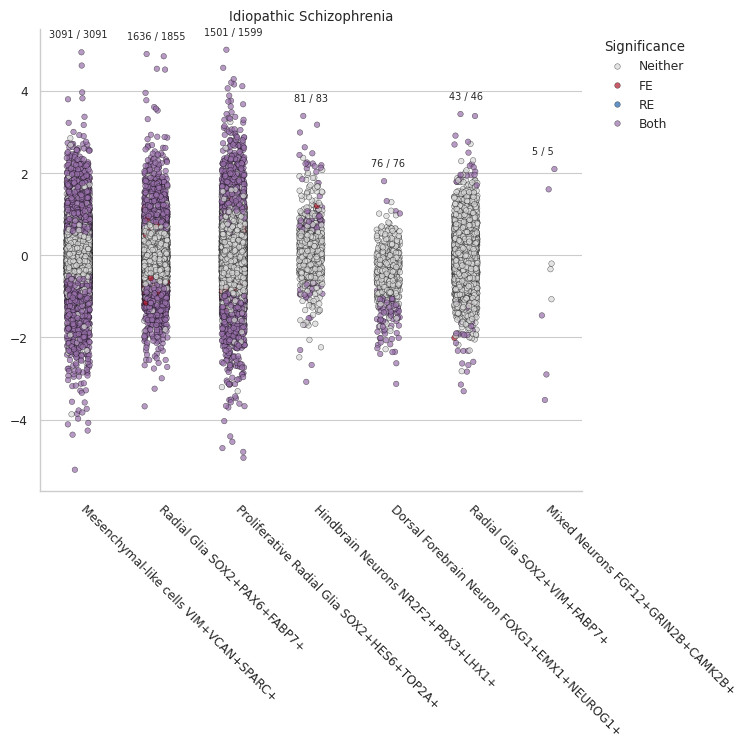

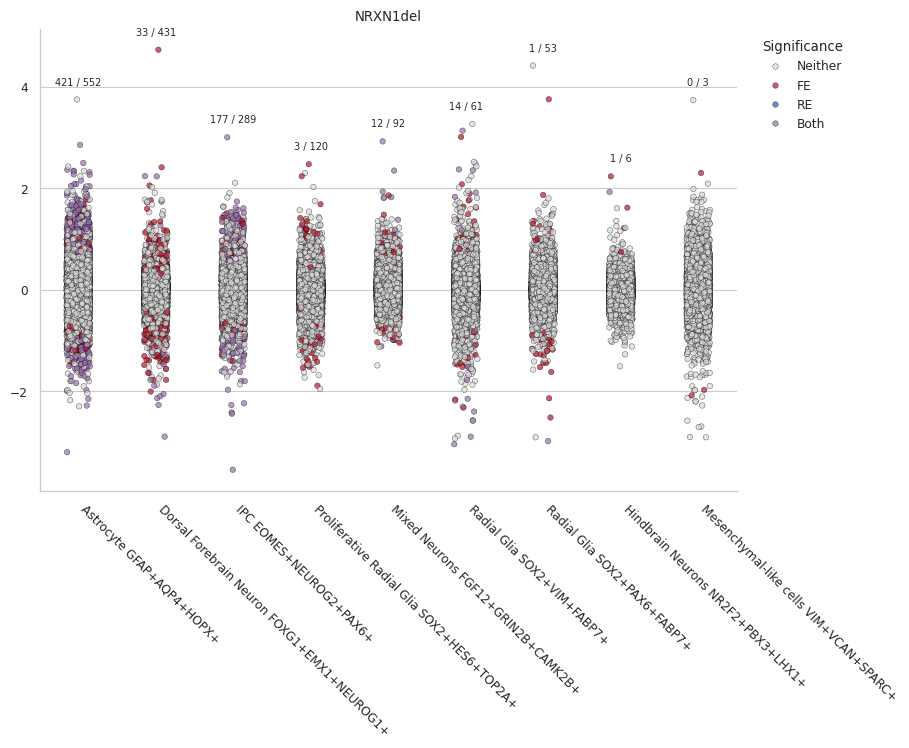

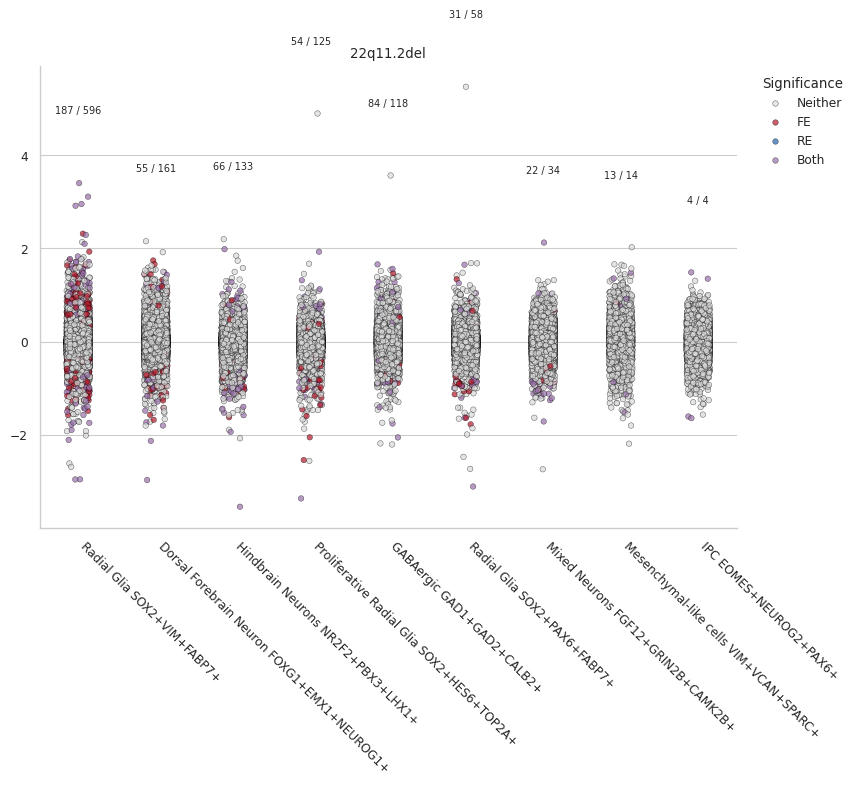

In [123]:
sig_palette = {
    "Neither": "#D9D9D9",
    "FE": "#b2182b",
    "RE": "#2166ac",
    "Both": "#9970AB"
}

for disease in comparison["group"].unique():

    temp_df = comparison[comparison["group"] == disease].copy()

    sig_counts = (
        temp_df[temp_df["Significance"] != "Neither"]
        .groupby("assay").size()
    )

    present_assays = (
        sig_counts.rename("n").reset_index()
        .sort_values(["n", "assay"], ascending=[False, True])["assay"]
        .tolist()
    )

    fig, ax = plt.subplots(figsize=(len(present_assays), 6))

    sns.stripplot(
        data=temp_df, x="assay", y="estimate_FE",
        order=present_assays, hue="Significance",
        hue_order=["Neither", "FE", "RE", "Both"],
        palette=sig_palette, jitter=0.15, size=4,
        alpha=0.7, edgecolor="black", linewidth=0.3, ax=ax
    )

    ax.set_title(disease)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.legend(title="Significance", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    sns.despine()
    plt.xticks(rotation=-45, ha="left")

    yrange = temp_df["estimate_FE"].max() - temp_df["estimate_FE"].min()

    for x, assay in enumerate(present_assays):
        y = temp_df.loc[temp_df["assay"] == assay, "estimate_FE"].max()
        fe_n = temp_df.loc[temp_df["assay"] == assay, "FE_sig"].sum()
        re_n = temp_df.loc[temp_df["assay"] == assay, "RE_sig"].sum()

        ax.text(
            x, y + 0.03 * yrange,
            f"{re_n} / {fe_n}",
            ha="center", va="bottom", fontsize=7
        )

    # plt.tight_layout()
    plt.savefig(f'/home/deepak/datasets/scz_meta_analysis/panels/Supplemental_Figure_RE_Comparison_stripplot_{disease}_effect.png')
    plt.show()

In [102]:
comparison['estimate_FE'].corr(comparison['estimate_RE'])

0.9977325298054661

In [103]:
comparison[['estimate_FE', 'estimate_RE']].describe()

,estimate_FE,estimate_RE
count,238682.000000,238682.000000
mean,0.005739,0.005615
std,0.858505,0.860053
min,-23.787719,-23.787719
25%,-0.148761,-0.152599
50%,-0.000615,-0.000856
75%,0.146585,0.151002
max,24.160049,24.160049


In [114]:
temp

,ID,assay,estimate_FE,std.error_FE,statistic_FE,p.value_FE,n.studies_FE,method_FE,assay_ID_FE,p.adjusted_FE,...,method_RE,assay_ID_RE,p.adjusted_RE,significant_fdr_RE,delta_effect,delta_se,FE_sig,RE_sig,assay_disease,Significance


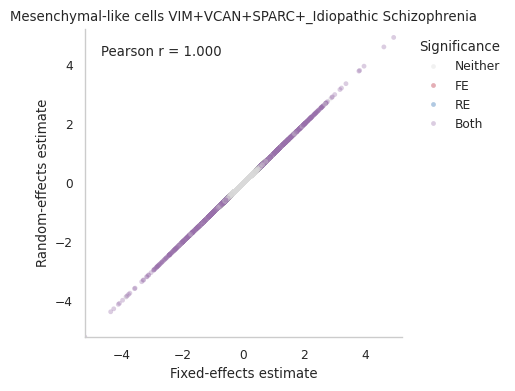

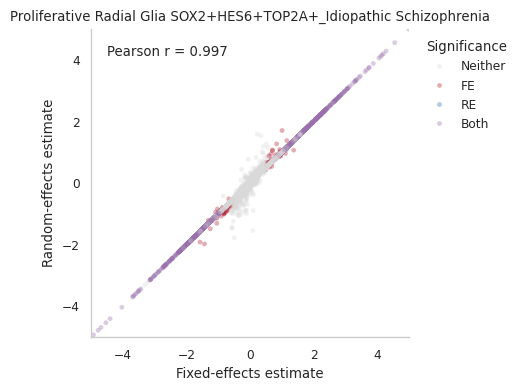

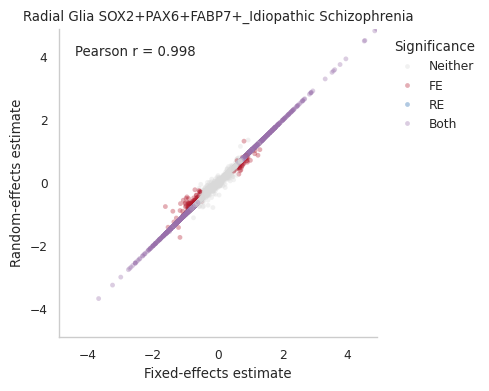

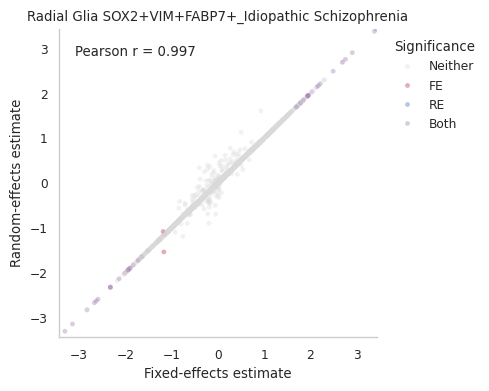

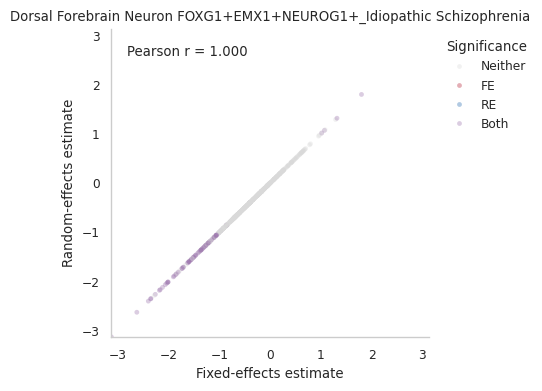

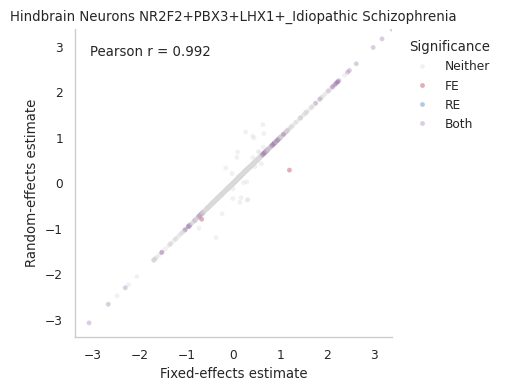

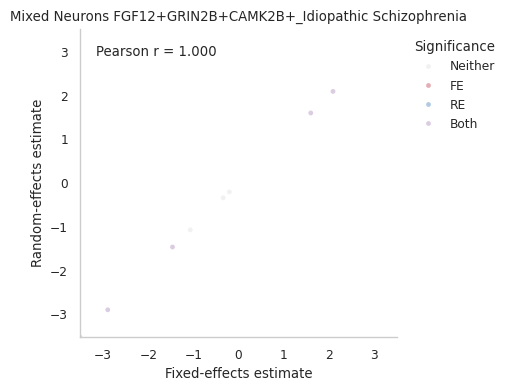

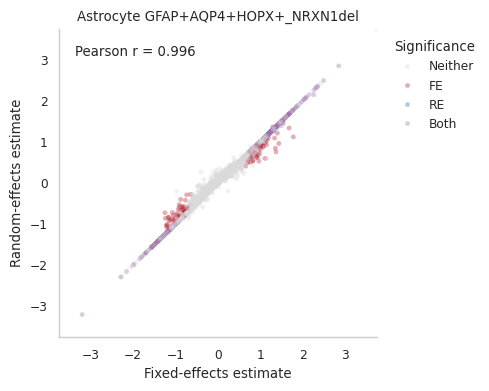

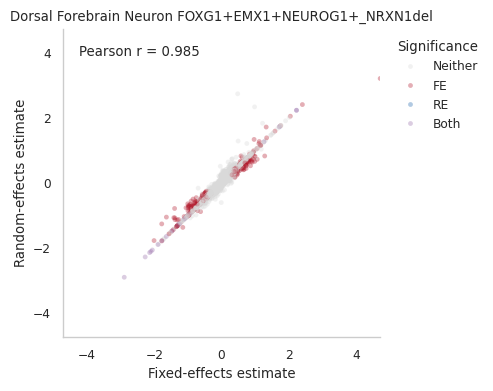

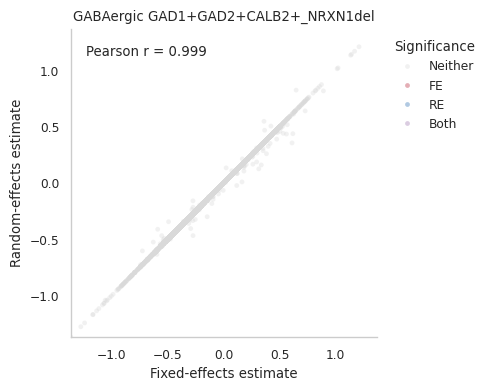

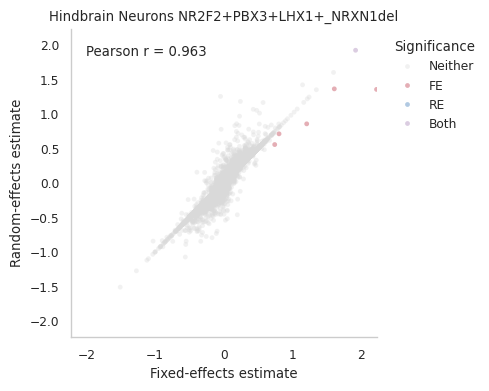

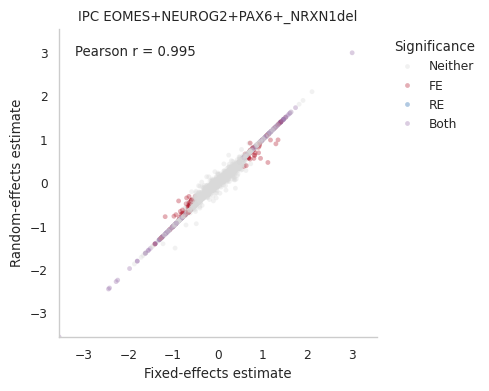

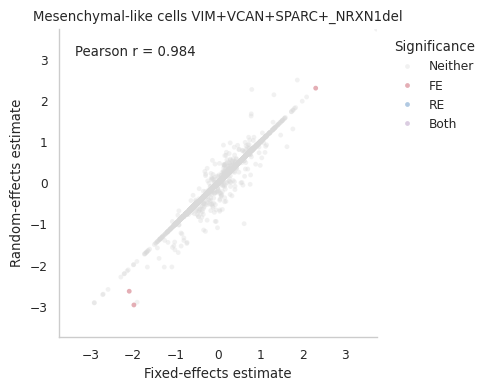

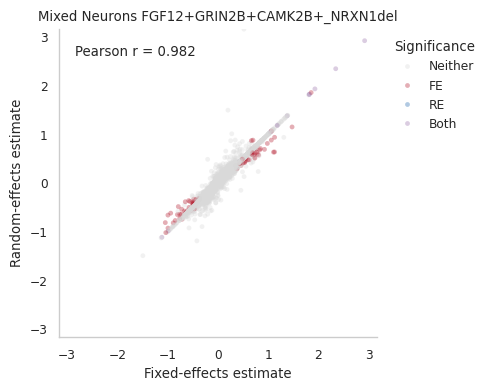

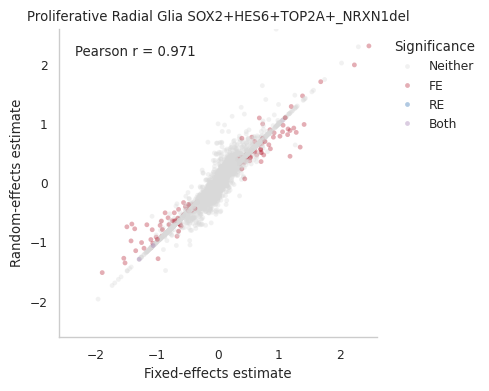

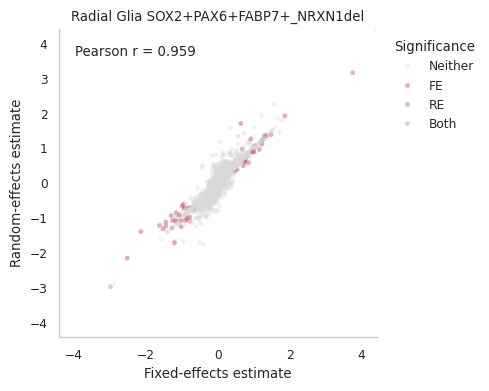

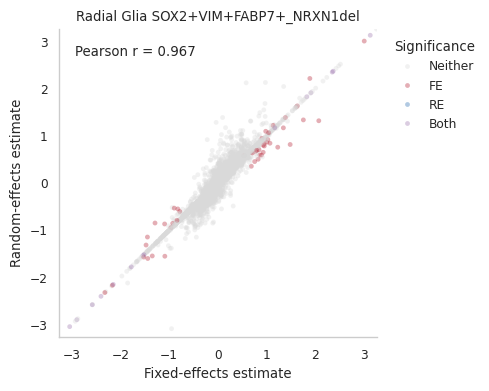

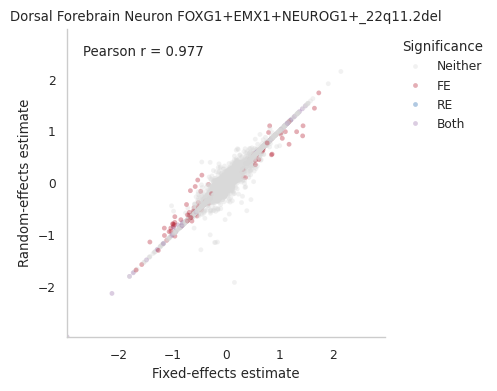

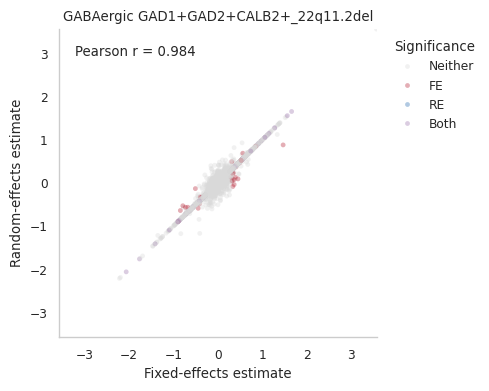

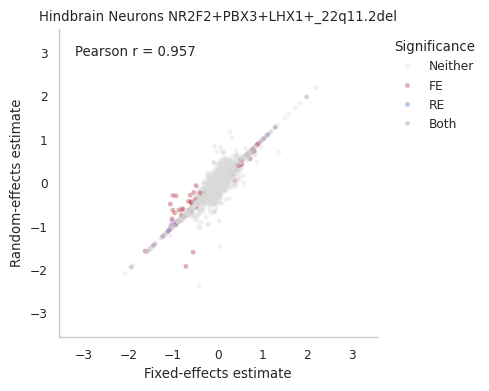

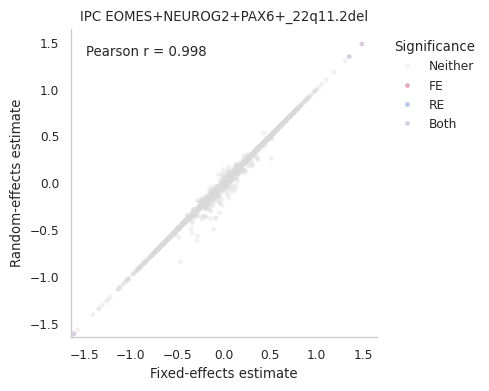

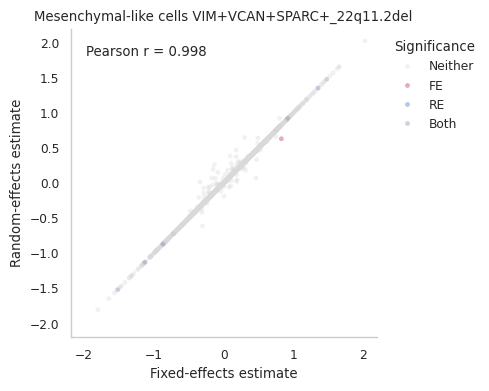

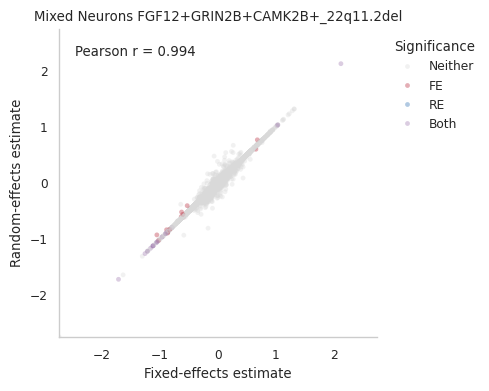

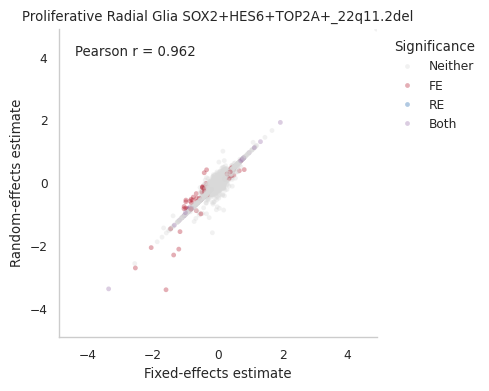

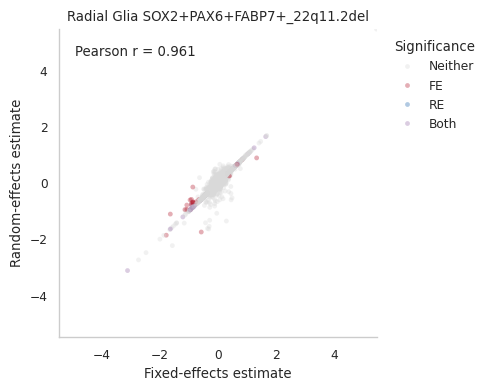

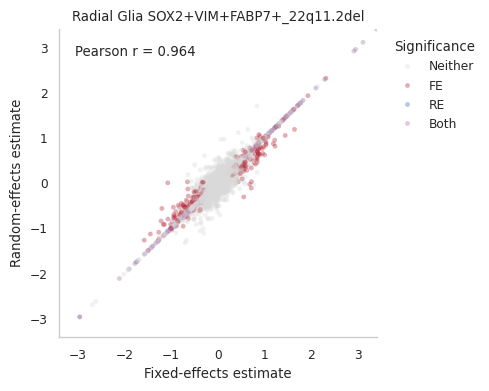

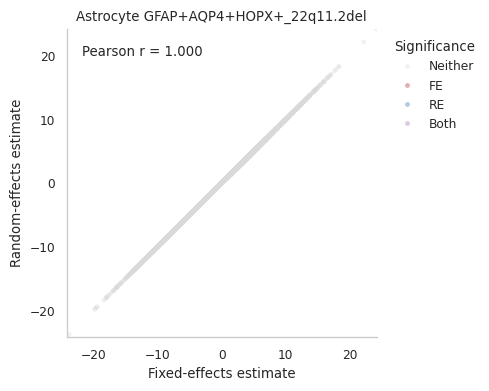

In [122]:
sig_palette = {"Neither":"#D9D9D9","FE":"#b2182b","RE":"#2166ac","Both":"#9970AB"}

for celltype_disease in comparison['assay_disease'].unique():
    
    temp = comparison[comparison["assay_disease"] == celltype_disease]

    if temp.shape[0] == 0:
        continue
    
    fig, ax = plt.subplots(figsize=(5,4))

    sns.scatterplot(data=temp, x="estimate_FE", y="estimate_RE", hue="Significance",
                    hue_order=["Neither","FE","RE","Both"], palette=sig_palette,
                    alpha=.35, s=12, linewidth=0, ax=ax)

    lim = np.nanmax(np.abs(pd.concat([temp["estimate_FE"],temp["estimate_RE"]])))
    # ax.plot([-lim,lim],[-lim,lim],"--",color="black",lw=1)

    r = temp[["estimate_FE","estimate_RE"]].corr().iloc[0,1]
    
    ax.text(.05,.95,f"Pearson r = {r:.3f}",transform=ax.transAxes,va="top")

    ax.set(xlim=(-lim,lim),ylim=(-lim,lim),title=celltype_disease,
           xlabel="Fixed-effects estimate",ylabel="Random-effects estimate")
    
    ax.legend(title="Significance",bbox_to_anchor=(1.02,1),loc="upper left",frameon=False)
    ax.grid(False)
    
    sns.despine()
    plt.tight_layout()
    plt.savefig(f'/home/deepak/datasets/scz_meta_analysis/panels/Supplemental_Figure_RE_Comparison_scatterplot_{celltype_disease}_effect.png')
    plt.show()